In [1]:
# Imports
from pathlib import Path
from experiment.utils import TrainedModel, TrainedModelID, get_losses

import pandas as pd
import torch
from neuralhydrology.nh_run import start_run, eval_run, finetune
from experiment.eval import evaluate_models
import os
import yaml
import matplotlib.pyplot as plt

In [10]:
model = TrainedModel(TrainedModelID.SOTA_20)

df = pd.read_csv(model.metrics_file, dtype={'basin':str})
cutoff = 0.0
basin_data = df.loc[df['NSE'] > cutoff].sample(n=1)
basin = basin_data.basin.iloc[0]
nse = basin_data.NSE.iloc[0]
basin

'05362000'

In [11]:
# Add the path to the pre-trained model to the finetune config
file_path = "finetune.yml"

with open(file_path, "a") as fp:
    fp.write(f"\nbase_run_dir: {model.run_dir.absolute()}")

# Load the existing YAML data
with open(file_path, 'r') as f:
    data = yaml.safe_load(f)

data['experiment_name'] = f'basin_{basin}'  # Example modification

# Write back to the YAML file
with open(file_path, 'w') as f:
    yaml.dump(data, f)   


In [12]:
# Create a basin file with the basin we selected above
with open("finetune_basin.txt", "w") as fp:
    fp.write(basin)

In [ ]:
finetune(Path('finetun.yml'))

2024-09-19 16:29:40,367: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-19 16:29:40,368: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-19 16:29:40,369: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-19 16:29:40,371: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


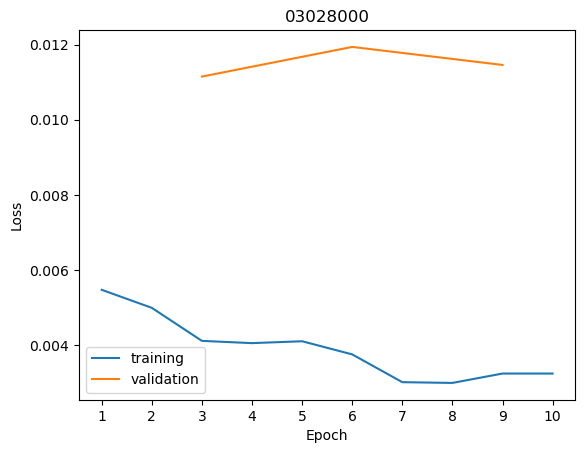

In [6]:
run_dir = Path(os.path.abspath('')) / 'runs' / f'basin_{basin}'
config_file_path = run_dir / 'config.yml'
output_log = run_dir / 'output.log'

# plot the training and validation loss
train, val = get_losses(output_log)
train_epoch, train_ls = zip(*train.items()) 
val_epoch, val_ls = zip(*val.items()) 

plt.plot(train_epoch, train_ls, label='training')
plt.plot(val_epoch, val_ls, label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{basin}')
plt.legend()


In [9]:
finetuned_model = TrainedModel(config_file_path_or_experiment_name=config_file_path)
evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='train')
evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='test')

,Metric,sota_20
0,NSE (mean),0.94
1,KGE (mean),0.9
2,Alpha-NSE (mean),0.92
3,Beta-NSE (mean),-0.03
4,MSE (mean),0.4
5,RMSE (mean),0.63
6,Pearson-r (mean),0.97
7,Beta-KGE (mean),0.96
8,FHV (mean),-8.43
9,FMS (mean),-13.83


,Metric,basin_03028000
0,NSE (mean),nan
1,KGE (mean),nan
2,MSE (mean),nan
3,NSE (median),nan
4,KGE (median),nan
5,MSE (median),nan


,Metric,sota_20
0,NSE (mean),0.79
1,KGE (mean),0.79
2,Alpha-NSE (mean),0.82
3,Beta-NSE (mean),-0.01
4,MSE (mean),1.41
5,RMSE (mean),1.19
6,Pearson-r (mean),0.89
7,Beta-KGE (mean),0.98
8,FHV (mean),-17.46
9,FMS (mean),-10.88


,Metric,basin_03028000
0,NSE (mean),nan
1,KGE (mean),nan
2,MSE (mean),nan
3,NSE (median),nan
4,KGE (median),nan
5,MSE (median),nan


,Metric,basin_03028000
0,NSE (mean),<b>nan</b>
1,KGE (mean),<b>nan</b>
2,MSE (mean),<b>nan</b>
3,NSE (median),<b>nan</b>
4,KGE (median),<b>nan</b>
5,MSE (median),<b>nan</b>


In [28]:
import pandas as pd
model = TrainedModel(TrainedModelID.SOTA_20)
metric = 'NSE'
fine_m = pd.read_csv(os.path.join('assets', model.config_id, 'finetuned_metrics.csv'), index_col='Metric').transpose().reset_index(drop=False).rename(columns={'index': 'basin'})
sota_m = pd.read_csv('../models/runs/sota_20/test/model_epoch030/test_metrics.csv', dtype={'basin':str})


In [29]:
fine_m = fine_m.map(lambda x: x.replace('<b>', '').replace('</b>',''))


In [30]:
merged_df = pd.merge(left=sota_m[['basin', f'{metric}']], right=fine_m[['basin', f'{metric} (mean)']], on='basin')
merged_df[f'{metric} (mean)'] = merged_df[f'{metric} (mean)'].astype(float)

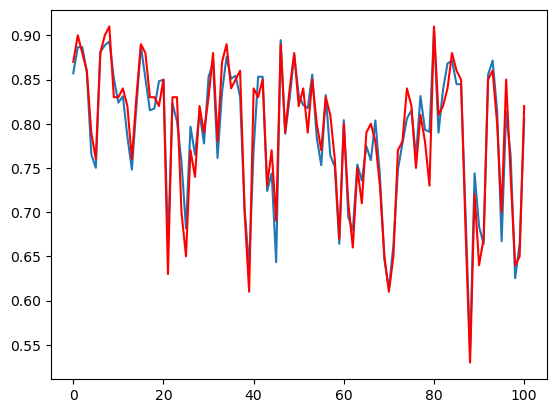

In [31]:
plt.plot(merged_df[f'{metric}'])
plt.plot(merged_df[f'{metric} (mean)'], 'r')


In [32]:
merged_df = merged_df.set_index('basin')

In [33]:
merged_df.mean(axis=0)

NSE           0.787824
NSE (mean)    0.789307
dtype: float64